In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from decimal import Decimal, getcontext, ROUND_HALF_EVEN

# Методичка

In [ ]:
# ВНИМАНИЕ! в этой ячейке злостный вайбкод, но я его тестил

def round_err(epsilon_raw):
    """
    Округляет погрешность по правилам:
      - если первая значащая цифра 1–3 → 2 значащие;
      - иначе → 1 значащая.
    Возвращает:
        (ε_rounded: float, ε_str: str)
    """
    if epsilon_raw is None or math.isnan(epsilon_raw):
        return float('nan'), "undefined"
    if epsilon_raw == 0:
        return "0"

    n_sig = significant_digits_count(epsilon_raw)
    eps_rounded = round_to_significant_decimal(epsilon_raw, n_sig)

    # вычисляем, сколько знаков после запятой нужно
    if eps_rounded < 1:
        dec_places = decimal_places_for_value_decimal(eps_rounded, n_sig)
    else:
        exp_rel = math.floor(math.log10(eps_rounded))
        dec_places = max(0, n_sig - 1 - exp_rel)

    # без ".0", если dec_places == 0
    eps_str = format_number_decimal(eps_rounded, dec_places, force_decimals=(dec_places > 0))
    return eps_str


getcontext().prec = 40

def significant_digits_count(value):
    if value == 0 or (isinstance(value, float) and math.isnan(value)):
        return 1
    d = Decimal(str(value)).normalize()
    s = ''.join(map(str, d.as_tuple().digits))
    if not s:
        return 1
    first = int(s[0])
    return 2 if first in (1,2,3) else 1

def round_to_significant_decimal(x, n):
    """Возвращает Decimal, округлённый до n значащих цифр (half-even)."""
    if x == 0:
        return Decimal(0)
    d = Decimal(str(x))
    exponent = d.adjusted()  # как floor(log10(|d|))
    q_exp = exponent - n + 1
    q = Decimal(1).scaleb(q_exp)  # 10**q_exp
    rounded = d.quantize(q, rounding=ROUND_HALF_EVEN)
    return rounded

def decimal_places_for_value_decimal(delta_decimal):
    """Число знаков после запятой, соответствующих младшему разряду Decimal delta."""
    if delta_decimal == 0:
        return 0
    d = delta_decimal.normalize()
    exp = d.as_tuple().exponent
    if exp >= 0:
        return 0
    return -exp

def format_number_decimal(value_decimal, decimal_places, force_decimals=False):
    """Форматирует Decimal: если decimal_places==0 и force_decimals==False — без '.0'."""
    if decimal_places > 0 or force_decimals:
        q = Decimal(1).scaleb(-decimal_places)
        s = str(value_decimal.quantize(q, rounding=ROUND_HALF_EVEN))
        if s.startswith("-0"):
            s = s.lstrip("-")
        return s
    return str(int(value_decimal.to_integral_value(rounding=ROUND_HALF_EVEN)))

def get_measurement_components(V, deltaV, N=None):
    abs_delta = abs(deltaV)
    if abs_delta == 0:
        str_delta = "0"
        Vd = Decimal(str(V))
        str_V = str(int(Vd)) if Vd == Vd.to_integral_value() else str(V)
        str_relative = "0%"
        return str_V, str_delta, str_relative

    n_sig = significant_digits_count(abs_delta)
    rounded_delta_dec = round_to_significant_decimal(abs_delta, n_sig)
    dec_places = decimal_places_for_value_decimal(rounded_delta_dec)

    V_dec = Decimal(str(V))
    if dec_places > 0:
        q = Decimal(1).scaleb(-dec_places)
        V_rounded = V_dec.quantize(q, rounding=ROUND_HALF_EVEN)
    else:
        V_rounded = V_dec.to_integral_value(rounding=ROUND_HALF_EVEN)

    str_V = format_number_decimal(V_rounded, dec_places, force_decimals=(dec_places>0))
    str_delta = format_number_decimal(rounded_delta_dec, dec_places, force_decimals=(dec_places>0))

    if V == 0:
        str_relative = "undefined"
    else:
        relative = abs(deltaV / V) * 100
        if relative == 0:
            str_relative = "0%"
        else:
            n_rel = significant_digits_count(relative)
            rounded_rel_dec = round_to_significant_decimal(relative, n_rel)
            rel_dp = decimal_places_for_value_decimal(rounded_rel_dec)
            rel_str = format_number_decimal(rounded_rel_dec, rel_dp, force_decimals=(rel_dp>0))
            str_relative = f"{rel_str}%"

    return str_V, str_delta, str_relative

def format_result(V, deltaV, N=None, latex=False, include_rel=False):
    sV, sD, sR = get_measurement_components(V, deltaV, N)
    if latex:
        prefix = f"(" if N is not None else ""
        base = f"{sV} \\pm {sD}"
        suffix = f") \\cdot 10^{{{N}}}" if N is not None else ""
        rel = f", \\varepsilon={sR}" if include_rel else ""
        return prefix + base + suffix + rel
    else:
        base = f"{sV} ± {sD}"
        suffix = f" × 10^{N}" if N is not None else ""
        rel = f", ε={sR}" if include_rel else ""
        return base + suffix + rel

# Алиасы
def format_std(V, deltaV, N=None): return format_result(V, deltaV, N, latex=False, include_rel=False)
def format_rel(V, deltaV, N=None): return format_result(V, deltaV, N, latex=False, include_rel=True)
def latex_std(V, deltaV, N=None): return format_result(V, deltaV, N, latex=True, include_rel=False)
def latex_rel(V, deltaV, N=None): return format_result(V, deltaV, N, latex=True, include_rel=True)

# 3.00

##### Задание 1. Исследование сигналов различной формы

In [ ]:
# INPUT

signal_sinus = {
    "CH1": ["auto", "Δ auto", "cursor", "Δ cursor", "generator", "Δ generator"],
    "frequency":  [5000, 50, 5000, 13, 5000, 1],
    "voltage":    [0.980, 0.020, 1.030, 0.004, 1.000, 0.001],
    "period, us": [200, 1, 200, 1, 200, 0.001]
}

signal_meandr = {
    "CH1": ["auto", "Δ auto", "cursor", "Δ cursor", "generator", "Δ generator"],
    "frequency":  [5000, 50, 5000, 13, 5000, 1],
    "voltage":    [1.000, 0.020, 1.005, 0.004, 1.000, 0.001],
    "period, us": [200, 1, 200, 1, 200, 0.001]
}

signal_ramp = {
    "CH1": ["auto", "Δ auto", "cursor", "Δ cursor", "generator", "Δ generator"],
    "frequency":  [5000, 50, 5000, 13, 5000, 1],
    "voltage":    [0.980, 0.020, 1.020, 0.004, 1.000, 0.001],
    "period, us": [200, 1, 200, 1, 200, 0.001]
}

In [ ]:
df_sinus = pd.DataFrame(signal_sinus).set_index("CH1").T
df_meandr = pd.DataFrame(signal_meandr).set_index("CH1").T
df_ramp = pd.DataFrame(signal_ramp).set_index("CH1").T

In [ ]:
for df in [df_sinus, df_meandr, df_ramp]:
    df["auto/gen, %"] = abs(df["generator"] - df["auto"]) / df["generator"] * 100
    df["cursor/gen, %"] = abs(df["generator"] - df["cursor"]) / df["generator"] * 100

In [ ]:
df_sinus

CH1,auto,Δ auto,cursor,Δ cursor,generator,Δ generator,"auto/gen, %","cursor/gen, %"
frequency,5000.00,50.00,5000.00,13.000,5000.0,1.000,0.0,0.0
voltage,0.98,0.02,1.03,0.004,1.0,0.001,2.0,3.0
"period, us",200.00,1.00,200.00,1.000,200.0,0.001,0.0,0.0


Отчёт

In [ ]:
p_1D1 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Измерения для синусоидального сигнала}}
\\begin{{tabular}}{{|c|c|c|c|}}\\hline
& \\makecell{{Автоматические\\\\измерения}} & \\makecell{{Измерения\\\\с помощью курсора}} & \\makecell{{ГС АКИП-3409}} \\\\ \\hline
\\makecell{{Частота\\\\сигнала, Гц}} & ${latex_std(df_sinus.loc['frequency', 'auto'], df_sinus.loc['frequency', 'Δ auto'])}$ & ${latex_std(df_sinus.loc['frequency', 'cursor'], df_sinus.loc['frequency', 'Δ cursor'])}$ & ${latex_std(df_sinus.loc['frequency', 'generator'], df_sinus.loc['frequency', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Амплитуда\\\\сигнала, В}} & ${latex_std(df_sinus.loc['voltage', 'auto'], df_sinus.loc['voltage', 'Δ auto'])}$ & ${latex_std(df_sinus.loc['voltage', 'cursor'], df_sinus.loc['voltage', 'Δ cursor'])}$ & ${latex_std(df_sinus.loc['voltage', 'generator'], df_sinus.loc['voltage', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Период, мкс}} & ${latex_std(df_sinus.loc['period, us', 'auto'], df_sinus.loc['period, us', 'Δ auto'])}$ & ${latex_std(df_sinus.loc['period, us', 'cursor'], df_sinus.loc['period, us', 'Δ cursor'])}$ & ${latex_std(df_sinus.loc['period, us', 'generator'], df_sinus.loc['period, us', 'Δ generator'])}$ \\\\ \\hline
\\end{{tabular}}
\\end{{table}}"""

p_1D2 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Измерения для меандра}}
\\begin{{tabular}}{{|c|c|c|c|}}\\hline
& \\makecell{{Автоматические\\\\измерения}} & \\makecell{{Измерения\\\\с помощью курсора}} & \\makecell{{ГС АКИП-3409}} \\\\ \\hline
\\makecell{{Частота\\\\сигнала, Гц}} & ${latex_std(df_meandr.loc['frequency', 'auto'], df_meandr.loc['frequency', 'Δ auto'])}$ & ${latex_std(df_meandr.loc['frequency', 'cursor'], df_meandr.loc['frequency', 'Δ cursor'])}$ & ${latex_std(df_meandr.loc['frequency', 'generator'], df_meandr.loc['frequency', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Амплитуда\\\\сигнала, В}} & ${latex_std(df_meandr.loc['voltage', 'auto'], df_meandr.loc['voltage', 'Δ auto'])}$ & ${latex_std(df_meandr.loc['voltage', 'cursor'], df_meandr.loc['voltage', 'Δ cursor'])}$ & ${latex_std(df_meandr.loc['voltage', 'generator'], df_meandr.loc['voltage', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Период, мкс}} & ${latex_std(df_meandr.loc['period, us', 'auto'], df_meandr.loc['period, us', 'Δ auto'])}$ & ${latex_std(df_meandr.loc['period, us', 'cursor'], df_meandr.loc['period, us', 'Δ cursor'])}$ & ${latex_std(df_meandr.loc['period, us', 'generator'], df_meandr.loc['period, us', 'Δ generator'])}$ \\\\ \\hline
\\end{{tabular}}
\\end{{table}}"""

p_1D3 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Измерения для ramp сигнала}}
\\begin{{tabular}}{{|c|c|c|c|}}\\hline
& \\makecell{{Автоматические\\\\измерения}} & \\makecell{{Измерения\\\\с помощью курсора}} & \\makecell{{ГС АКИП-3409}} \\\\ \\hline
\\makecell{{Частота\\\\сигнала, Гц}} & ${latex_std(df_ramp.loc['frequency', 'auto'], df_ramp.loc['frequency', 'Δ auto'])}$ & ${latex_std(df_ramp.loc['frequency', 'cursor'], df_ramp.loc['frequency', 'Δ cursor'])}$ & ${latex_std(df_ramp.loc['frequency', 'generator'], df_ramp.loc['frequency', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Амплитуда\\\\сигнала, В}} & ${latex_std(df_ramp.loc['voltage', 'auto'], df_ramp.loc['voltage', 'Δ auto'])}$ & ${latex_std(df_ramp.loc['voltage', 'cursor'], df_ramp.loc['voltage', 'Δ cursor'])}$ & ${latex_std(df_ramp.loc['voltage', 'generator'], df_ramp.loc['voltage', 'Δ generator'])}$ \\\\ \\hline
\\makecell{{Период, мкс}} & ${latex_std(df_ramp.loc['period, us', 'auto'], df_ramp.loc['period, us', 'Δ auto'])}$ & ${latex_std(df_ramp.loc['period, us', 'cursor'], df_ramp.loc['period, us', 'Δ cursor'])}$ & ${latex_std(df_ramp.loc['period, us', 'generator'], df_ramp.loc['period, us', 'Δ generator'])}$ \\\\ \\hline
\\end{{tabular}}
\\end{{table}}"""

p_1E1 = f"""Относительные отклонения для синусоидального сигнала:
\\begin{{align*}}
\\varepsilon_{{f,\\;\\text{{авт–ген}}}} &= \\frac{{{df_sinus.loc['frequency', 'auto']} - {df_sinus.loc['frequency', 'generator']}}}{{{df_sinus.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['frequency', 'auto/gen, %'])}\\%, &
\\varepsilon_{{f,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_sinus.loc['frequency', 'cursor']} - {df_sinus.loc['frequency', 'generator']}}}{{{df_sinus.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['frequency', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{A,\\;\\text{{авт–ген}}}} &= \\frac{{{df_sinus.loc['voltage', 'auto']} - {df_sinus.loc['voltage', 'generator']}}}{{{df_sinus.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['voltage', 'auto/gen, %'])}\\%, &
\\varepsilon_{{A,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_sinus.loc['voltage', 'cursor']} - {df_sinus.loc['voltage', 'generator']}}}{{{df_sinus.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['voltage', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{T,\\;\\text{{авт–ген}}}} &= \\frac{{{df_sinus.loc['period, us', 'auto']} - {df_sinus.loc['period, us', 'generator']}}}{{{df_sinus.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['period, us', 'auto/gen, %'])}\\%, &
\\varepsilon_{{T,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_sinus.loc['period, us', 'cursor']} - {df_sinus.loc['period, us', 'generator']}}}{{{df_sinus.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_sinus.loc['period, us', 'cursor/gen, %'])}\\%.
\\end{{align*}}"""

p_1E2 = f"""Относительные отклонения для меандра:
\\begin{{align*}}
\\varepsilon_{{f,\\;\\text{{авт–ген}}}} &= \\frac{{{df_meandr.loc['frequency', 'auto']} - {df_meandr.loc['frequency', 'generator']}}}{{{df_meandr.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['frequency', 'auto/gen, %'])}\\%, &
\\varepsilon_{{f,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_meandr.loc['frequency', 'cursor']} - {df_meandr.loc['frequency', 'generator']}}}{{{df_meandr.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['frequency', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{A,\\;\\text{{авт–ген}}}} &= \\frac{{{df_meandr.loc['voltage', 'auto']} - {df_meandr.loc['voltage', 'generator']}}}{{{df_meandr.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['voltage', 'auto/gen, %'])}\\%, &
\\varepsilon_{{A,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_meandr.loc['voltage', 'cursor']} - {df_meandr.loc['voltage', 'generator']}}}{{{df_meandr.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['voltage', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{T,\\;\\text{{авт–ген}}}} &= \\frac{{{df_meandr.loc['period, us', 'auto']} - {df_meandr.loc['period, us', 'generator']}}}{{{df_meandr.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['period, us', 'auto/gen, %'])}\\%, &
\\varepsilon_{{T,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_meandr.loc['period, us', 'cursor']} - {df_meandr.loc['period, us', 'generator']}}}{{{df_meandr.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_meandr.loc['period, us', 'cursor/gen, %'])}\\%.
\\end{{align*}}"""

p_1E3 = f"""Относительные отклонения для ramp сигнала:
\\begin{{align*}}
\\varepsilon_{{f,\\;\\text{{авт–ген}}}} &= \\frac{{{df_ramp.loc['frequency', 'auto']} - {df_ramp.loc['frequency', 'generator']}}}{{{df_ramp.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['frequency', 'auto/gen, %'])}\\%, &
\\varepsilon_{{f,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_ramp.loc['frequency', 'cursor']} - {df_ramp.loc['frequency', 'generator']}}}{{{df_ramp.loc['frequency', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['frequency', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{A,\\;\\text{{авт–ген}}}} &= \\frac{{{df_ramp.loc['voltage', 'auto']} - {df_ramp.loc['voltage', 'generator']}}}{{{df_ramp.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['voltage', 'auto/gen, %'])}\\%, &
\\varepsilon_{{A,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_ramp.loc['voltage', 'cursor']} - {df_ramp.loc['voltage', 'generator']}}}{{{df_ramp.loc['voltage', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['voltage', 'cursor/gen, %'])}\\%, \\\\[4pt]
\\varepsilon_{{T,\\;\\text{{авт–ген}}}} &= \\frac{{{df_ramp.loc['period, us', 'auto']} - {df_ramp.loc['period, us', 'generator']}}}{{{df_ramp.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['period, us', 'auto/gen, %'])}\\%, &
\\varepsilon_{{T,\\;\\text{{ручн–ген}}}} &= \\frac{{{df_ramp.loc['period, us', 'cursor']} - {df_ramp.loc['period, us', 'generator']}}}{{{df_ramp.loc['period, us', 'generator']}}}\\cdot100\\% = {round(df_ramp.loc['period, us', 'cursor/gen, %'])}\\%.
\\end{{align*}}"""

print(p_1D1, p_1D2, p_1D3, sep='\n')

\begin{table}[H]
\centering
\caption{Измерения для синусоидального сигнала}
\begin{tabular}{|c|c|c|c|}\hline
& \makecell{Автоматические\\измерения} & \makecell{Измерения\\с помощью курсора} & \makecell{ГС АКИП-3409} \\ \hline
\makecell{Частота\\сигнала, Гц} & $5000 \pm 50$ & $5000 \pm 13$ & $5000 \pm 1$ \\ \hline
\makecell{Амплитуда\\сигнала, В} & $0.98 \pm 0.02$ & $1.030 \pm 0.004$ & $1.000 \pm 0.001$ \\ \hline
\makecell{Период, мкс} & $200 \pm 1$ & $200 \pm 1$ & $200.000 \pm 0.001$ \\ \hline
\end{tabular}
\end{table}
\begin{table}[H]
\centering
\caption{Измерения для меандра}
\begin{tabular}{|c|c|c|c|}\hline
& \makecell{Автоматические\\измерения} & \makecell{Измерения\\с помощью курсора} & \makecell{ГС АКИП-3409} \\ \hline
\makecell{Частота\\сигнала, Гц} & $5000 \pm 50$ & $5000 \pm 13$ & $5000 \pm 1$ \\ \hline
\makecell{Амплитуда\\сигнала, В} & $1.00 \pm 0.02$ & $1.005 \pm 0.004$ & $1.000 \pm 0.001$ \\ \hline
\makecell{Период, мкс} & $200 \pm 1$ & $200 \pm 1$ & $200.000 \pm 0.001$ \\

##### Задание 2. Определение рабочих диапазонов приборов

Был измерен сигнал меандра на разных частотах (от 2 Гц до 10МГц). Около самой высокой частоты меандр перестаёт правильно отображаеться.

На низких частотах автоматический режим не может измерить частоту.

##### Задание 3. Изучение сложения однонаправленных колебаний, мало отличающихся по частоте (биения).

На каналы 1 и 2 были поданы сигналы с амплитудой 1В, фазой 0° и частотами 1000Гц и 1070Гц соответсвенно.

При суммировании получился сигнал с амплитудой 2.06В, периодом биений 1.02мс, частотой 980.4Гц.

Максимальная амплитуда при биениях $A = 2B$

In [ ]:
U0 = 1
freq1, freq2 = 1000, 1070

# INPUT U, T, freq
U = 2.06
T = 14e-3
freq = 71

Отклонение реального от теоретического, %

In [ ]:
Eps = round((U - 2*U0)/(2*U0) * 100)
print(f'{Eps}%')

3%


##### Задание 4. Изучение сложения взаимно перпендикулярных колебаний кратных частот (фигуры Лиссажу)

*Фигуры Лиссажу, полученные при разных фазах и соотношениях частот*

In [ ]:
# INPUT Разность фаз на генераторе, сооттношение
phi = 60
relation = "1:1"
# INPUT 2Uy1 (деления), 2Uymax (деления)
Uy1 = 22
Uymax = 26
d_Uy = 1

Сдвиг фаз между сигналами

$\alpha = \arcsin{\left(\frac{U_{Y1}}{U_{Ymax}}\right)}$


$\Delta_{\alpha} = \frac{U_{Y1}}{U_{Ymax}} \sqrt{\frac{\left(\frac{\Delta_{U_Y}}{U_{Y1}}\right)^2 + \left(\frac{\Delta_{U_Y}}{U_{Ymax}}\right)^2}{1-\left(\frac{U_{Y1}}{U_{Ymax}}\right)^2}}$

In [ ]:
alpha = np.arcsin(Uy1/Uymax)
d_alpha = Uy1 / Uymax * np.sqrt(((d_Uy/Uy1)**2 + (d_Uy/Uymax)**2)/(1 - (Uy1/Uymax)**2))
alpha, d_alpha = math.degrees(alpha), math.degrees(d_alpha)
print("alpha =", format_rel(alpha, d_alpha))

alpha = 58 ± 5, ε=9%


Отклонение реального от теоретического, %

In [ ]:
Eps = round(abs(alpha - phi)/(phi) * 100)
print(f'{Eps}%')

4%


##### Задание 5. Изучение сложения однонаправленных колебаний, мало отличающихся по частоте (биения)

In [ ]:
# INPUT f, ΔV
f = 1000
d_V = 0.02

# INPUT V B, Phi degrees
direct_meas = {
    "U1":     [1.3, 1.0,  1.5,  1.2],
    "alpha1": [0,   15,   30,   45],
    "U2":     [1.0, 0.8,  1.1,  1.0],
    "alpha2": [30,  60,   90,   120],
    "U":      [2.4, 1.76, 2.42, 1.88]
}

$U = \sqrt{U_1^2 + U_2^2 + 2U_1U_2\cos{(\alpha_2 - \alpha_1)}}$

In [ ]:
df = pd.DataFrame(direct_meas)
df['U theory'] = round(np.sqrt(df['U1']**2 + df['U2']**2 + 2*df['U1']*df['U2']*np.cos(np.radians(df['alpha2'] - df['alpha1']))), 3)
df['E'] = round(abs(df['U theory'] - df['U']) / df['U theory'] * 100)
df

,U1,alpha1,U2,alpha2,U,U theory,E
0,1.3,0,1.0,30,2.40,2.223,8.0
1,1.0,15,0.8,60,1.76,1.665,6.0
2,1.5,30,1.1,90,2.42,2.261,7.0
3,1.2,45,1.0,120,1.88,1.750,7.0


In [ ]:
p_5D = r"""\begin{table}[H]
\centering
\caption{Результаты измерений и теоретического значения амплитуды}
\begin{tabular}{|c|c|c|c|c|c|c|c|}\hline
№ &
$U_1,\text{ В}$ & $\alpha_1,^\circ$ &
$U_2,\text{ В}$ & $\alpha_2,^\circ$ &
\makecell{$U,\text{ В}$} &
\makecell{$U_{\text{теор.}}$, В} &
\makecell{$\varepsilon$, \%}
\\ \hline
"""

for i, row in df.iterrows():
    p_5D += f"{i+1} & {row['U1']} & {round(row['alpha1'])} & {row['U2']} & {round(row['alpha2'])} & {row['U']} & {row['U theory']} & {round_err(row['E'])} \\\\ \\hline\n"

p_5D += r"\end{tabular}" + "\n\\end{table}"

In [ ]:
print(p_5D)

\begin{table}[H]
\centering
\caption{Результаты измерений и теоретического значения амплитуды}
\begin{tabular}{|c|c|c|c|c|c|c|c|}\hline
№ &
$U_1,\text{ В}$ & $\alpha_1,^\circ$ &
$U_2,\text{ В}$ & $\alpha_2,^\circ$ &
\makecell{$U,\text{ В}$} &
\makecell{$U_{\text{теор.}}$, В} &
\makecell{$\varepsilon$, \%}
\\ \hline
1 & 1.3 & 0 & 1.0 & 30 & 2.4 & 2.223 & 8 \\ \hline
2 & 1.0 & 15 & 0.8 & 60 & 1.76 & 1.665 & 6 \\ \hline
3 & 1.5 & 30 & 1.1 & 90 & 2.42 & 2.261 & 7 \\ \hline
4 & 1.2 & 45 & 1.0 & 120 & 1.88 & 1.75 & 7 \\ \hline
\end{tabular}
\end{table}


# Простые линейные цепи

In [ ]:
R1 = 68.0
d_R1 = 6.8
L1 = 0.010
d_L1 = 0.001
C3 = 0.047e-6
d_C3 = 0.0047e-6

### RL-цепь

##### Задание 1

In [ ]:
# INPUT ΔU
d_U = 0.02

In [ ]:
# INPUT {f: [U in, U out]}
Direct_RL = {
    10:   [2.86, 1.76],
    100:  [2.84, 1.78],
    350:  [2.86, 1.78],
    700:  [2.86, 1.74],
    1000: [2.94, 1.78],
    1300: [3.02, 1.68],
    1500: [3.04, 1.68],
    1700: [3.10, 1.66],
    2000: [3.16, 1.56],
    2500: [3.30, 1.48],
    3000: [3.36, 1.36],
    4000: [3.52, 1.22],
    5000: [3.68, 1.08],
    6000: [3.78, 1.00],
    7000: [3.94, 0.92],
    9000: [4.00, 0.78],
    11000: [4.04, 0.68],
    13000: [4.06, 0.60],
    15000: [4.04, 0.56],
    20000: [4.12, 0.50],
    30000: [4.20, 0.34]
}

Эксперементальное
$K=\frac{U_{вых}}{U_{вх}}$

Погрешность
$\Delta_{K}=K\cdot\Delta_U\sqrt{\frac{1}{U_{вых}^2} + \frac{1}{U_{вх}^2}}$

In [ ]:
T_RL = pd.DataFrame.from_dict(Direct_RL, orient='index', columns=['U input', 'U output'])
T_RL.index.name = 'Frequency'
T_RL['K'] = T_RL['U output'] / T_RL['U input']
T_RL['ΔK'] = T_RL['K'] * d_U * np.sqrt(T_RL['U output']**(-2) + T_RL['U input']**(-2))

Теоретическое
$K_{RL}=\frac{R}{\sqrt{R^2 + (\omega L)^2}}$

Составим формулу погрешности для теоретического значения

$\varepsilon_{K_{RL}} = \sqrt{\left(\frac{\Delta_R}{R}\right)^2 + \frac{R^2\Delta_R^2 + (\omega L)^4((\frac{\Delta_\omega}{\omega})^2 + (\frac{\Delta_L}{L})^2)}{R^2+(\omega L)^2}}$

Учитывая, что $\omega=2\pi f$ и $\Delta_f=0$

$\Delta{K_{RL}} = K_{RL}\sqrt{\left(\frac{\Delta_R}{R}\right)^2 + \frac{R^2\Delta_R^2 + (2\pi f L)^4(\frac{\Delta_L}{L})^2}{R^2+(2\pi f L)^2}}$

In [ ]:
K_RL = lambda f: R1 / np.sqrt(R1**2 + (2 * np.pi * f * L1)**2)
T_RL['K theory'] = K_RL(T_RL.index)
d_K_RL = lambda f: ((d_R1/R1)**2 + (R1**2*d_R1**2 + (2 * np.pi * f * L1)**4*(d_L1/L1)**2)/(R1**2 + (2 * np.pi * f * L1)**2))**(-1/2)
T_RL['ΔK theory'] = d_K_RL(T_RL.index)

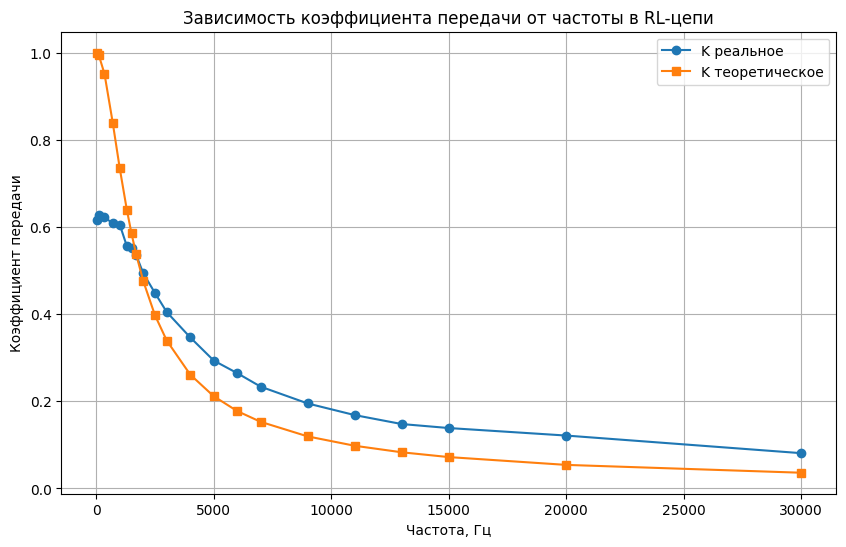

In [ ]:
df = T_RL.dropna()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['K'], label='K реальное', marker='o')
plt.plot(df.index, df['K theory'], label='K теоретическое', marker='s')

plt.xlabel('Частота, Гц')
plt.ylabel('Коэффициент передачи')
plt.title('Зависимость коэффициента передачи от частоты в RL-цепи')
plt.legend()
plt.grid(True, 'both')

# plt.xscale('log')
plt.show()

##### Задание 2

In [ ]:
# INPUT f, Δt, T
f = 1010
d_f = 5
dt = 60e-6
d_dt = 5e-6
T = 990e-6
d_T = 5e-6

omega = 2 * np.pi * f
d_omega = 2 * np.pi * d_f
print("ω =", format_rel(omega, d_omega))

ω = 6346 ± 31, ε=0.5%


$\varphi_{теор} = \arctan\frac{\omega L}{R}$

$\Delta_{\varphi_{теор}} = \frac{ \frac{\omega L}{R}\sqrt{\left(\frac{\Delta_\omega}{\omega}\right)^2 + \left(\frac{\Delta_L}{L}\right)^2 + \left(\frac{\Delta_R}{R}\right)^2} }{\left(\frac{\omega L}{R}\right)^2 + 1}$

$\varphi_1= 2\pi \frac{\Delta t}{T}$

$\Delta_{\varphi_1} = \varphi_1\sqrt{\left(\frac{\Delta_{\Delta t}}{\Delta t}\right)^2 + \left(\frac{\Delta_T}{T}\right)^2}$

In [ ]:
phi_theory = np.arctan(omega*L1/R1)
d_phi_theory = (omega*L1/R1)*np.sqrt((d_omega/omega)**2+(d_L1/L1)**2+(d_R1/R1)**2) / ((omega*L1/R1)**2 + 1)
print("φ теор =", format_rel(phi_theory, d_phi_theory))
phi_1 = 2 * np.pi * dt / T
d_phi_1 = phi_1 * np.sqrt((d_dt/dt)**2 + (d_T/T)**2)
print("φ1 =", format_rel(phi_1, d_phi_1))

φ теор = 0.75 ± 0.07, ε=9%
φ1 = 0.381 ± 0.032, ε=8%


##### Задание 3

In [ ]:
# INPUT 2Uy1 (деления), 2Uymax (деления)
Uy1 = 3
Uymax = 9
d_Uy = 1

$\varphi_2 = \arcsin{\frac{U_{Y1}}{U_{Ymax}}}$

$\Delta_{\varphi_2} = \frac{U_{Y1}}{U_{Ymax}} \sqrt{\frac{\left(\frac{\Delta_{U_Y}}{U_{Y1}}\right)^2 + \left(\frac{\Delta_{U_Y}}{U_{Ymax}}\right)^2}{1-\left(\frac{U_{Y1}}{U_{Ymax}}\right)^2}}$

In [ ]:
phi_2 = np.arcsin(Uy1/Uymax)
d_phi_2 = Uy1 / Uymax * np.sqrt(((d_Uy/Uy1)**2 + (d_Uy/Uymax)**2)/(1 - (Uy1/Uymax)**2))
print("φ 2 =", format_rel(phi_2, d_phi_2))

φ 2 = 0.34 ± 0.12, ε=37%


##### В отчёт

In [ ]:
p_RL2 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Сдвиг фаз через сдвиг сигналов}}
\\begin{{tabular}}{{|c|c|c|c|c|c|}}
\\hline
\\multicolumn{{2}}{{|c|}}{{Измеряем величины}} & \\multicolumn{{4}}{{c|}}{{Вычисляемые величины}} \\\\ \\hline
$f \\pm \\Delta f$ & $\\omega \\pm \\Delta \\omega$ & $\\Delta t \\pm \\Delta (\\Delta t)$ & $T \\pm \\Delta T$ & $\\varphi_1 \\pm \\Delta \\varphi_1$ & $\\varphi_{{\\text{{теор}}}} \\pm \\Delta \\varphi_{{\\text{{теор}}}}$ \\\\
Гц & рад/с & мкс & мкс & рад & рад \\\\ \\hline

{latex_std(f, d_f)} & {latex_std(omega, d_omega)} &
{latex_std(dt, d_dt)} & {latex_std(T, d_T)} &
{latex_std(phi_1, d_phi_1)} & {latex_std(phi_theory, d_phi_theory)} \\\\ \\hline

\\end{{tabular}}
\\end{{table}}"""

p_RL3 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Сдвиг фаз через фигуру Лиссажу}}
\\begin{{tabular}}{{|c|c|c|c|c|c|}}
\\hline
\\multicolumn{{3}}{{|c|}}{{Измеряемые величины}} & \\multicolumn{{2}}{{c|}}{{Вычисляемые величины}} \\\\ \\hline
$f \\pm \\Delta f$ & $\\omega \\pm \\Delta \\omega$ &  $2U_{{Y1}}$ & $U_{{Ymax}} & $\\varphi_2 \\pm \\Delta \\varphi_2$ & $\\varphi_{{\\text{{теор}}}} \\pm \\Delta \\varphi_{{\\text{{теор}}}}$ \\\\
Гц & рад/с & дел & дел & рад & рад \\\\ \\hline

${latex_std(f, d_f)}$ & ${latex_std(omega, d_omega)}$ &
${Uy1}$ & ${Uymax}$ &
${latex_std(phi_2, d_phi_2)}$ & ${latex_std(phi_theory, d_phi_theory)}$ \\\\ \\hline

\\end{{tabular}}
\\end{{table}}"""

In [ ]:
print(p_RL2)

\begin{table}[H]
\centering
\caption{Сдвиг фаз через сдвиг сигналов}
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multicolumn{2}{|c|}{Измеряем величины} & \multicolumn{4}{c|}{Вычисляемые величины} \\ \hline
$f \pm \Delta f$ & $\omega \pm \Delta \omega$ & $\Delta t \pm \Delta (\Delta t)$ & $T \pm \Delta T$ & $\varphi_1 \pm \Delta \varphi_1$ & $\varphi_{\text{теор}} \pm \Delta \varphi_{\text{теор}}$ \\
Гц & рад/с & мкс & мкс & рад & рад \\ \hline
  
1010 \pm 5 & 6346 \pm 31 & 
0.000060 \pm 0.000005 & 0.000990 \pm 0.000005 &
0.381 \pm 0.032 & 0.75 \pm 0.07 \\ \hline

\end{tabular}
\end{table}


In [ ]:
print(p_RL3)

\begin{table}[H]
\centering
\caption{Сдвиг фаз через фигуру Лиссажу}
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multicolumn{3}{|c|}{Измеряемые величины} & \multicolumn{2}{c|}{Вычисляемые величины} \\ \hline
$f \pm \Delta f$ & $\omega \pm \Delta \omega$ &  $2U_{Y1}$ & $U_{Ymax} & $\varphi_2 \pm \Delta \varphi_2$ & $\varphi_{\text{теор}} \pm \Delta \varphi_{\text{теор}}$ \\
Гц & рад/с & дел & дел & рад & рад \\ \hline

$1010 \pm 5$ & $6346 \pm 31$ & 
$3$ & $9$ &
$0.34 \pm 0.12$ & $0.75 \pm 0.07$ \\ \hline

\end{tabular}
\end{table}


In [ ]:
prefix = """\\begin{table}[H]
\\centering
\\caption{Результаты измерений и теоретические значения коэффициента передачи}
\\label{tab:measurements}
\\begin{tabular}{|c|c|c|c|c|}
\\hline
Частота, Гц & $U_{\\text{вх}}$, В & $U_{\\text{вых}}$, В & $K \\pm \\Delta K$ & $K_{\\text{теор}} \\pm \\Delta K_{\\text{теор}}$ \\\\ \\hline
"""

# Генерация строк таблицы
rows = []
for freq, row in df.iterrows():
    # Форматируем числа (убираем лишние нули)
    k_str = latex_std(row['K'], row['ΔK'])
    k_theory_str = latex_std(row['K theory'], row['ΔK theory'])

    # Создаем строку
    row_str = f"{int(freq)} & {row['U input']} & {row['U output']} & ${k_str}$ & ${k_theory_str}$ \\\\ \\hline"
    rows.append(row_str)

# Суффикс таблицы
suffix = """\\end{tabular}
\\end{table}"""

# Собираем всё вместе
p_RL1 = prefix + "\n".join(rows) + "\n" + suffix

In [ ]:
print(p_RL1)

\begin{table}[H]
\centering
\caption{Результаты измерений и теоретические значения коэффициента передачи}
\label{tab:measurements}
\begin{tabular}{|c|c|c|c|c|}
\hline
Частота, Гц & $U_{\text{вх}}$, В & $U_{\text{вых}}$, В & $K \pm \Delta K$ & $K_{\text{теор}} \pm \Delta K_{\text{теор}}$ \\ \hline
10 & 2.86 & 1.76 & $0.615 \pm 0.008$ & $1.00 \pm 0.15$ \\ \hline
100 & 2.84 & 1.78 & $0.627 \pm 0.008$ & $1.00 \pm 0.15$ \\ \hline
350 & 2.86 & 1.78 & $0.622 \pm 0.008$ & $0.95 \pm 0.15$ \\ \hline
700 & 2.86 & 1.74 & $0.608 \pm 0.008$ & $0.84 \pm 0.16$ \\ \hline
1000 & 2.94 & 1.78 & $0.605 \pm 0.008$ & $0.73 \pm 0.15$ \\ \hline
1300 & 3.02 & 1.68 & $0.556 \pm 0.008$ & $0.64 \pm 0.13$ \\ \hline
1500 & 3.04 & 1.68 & $0.553 \pm 0.008$ & $0.59 \pm 0.12$ \\ \hline
1700 & 3.1 & 1.66 & $0.535 \pm 0.007$ & $0.5 \pm 0.1$ \\ \hline
2000 & 3.16 & 1.56 & $0.494 \pm 0.007$ & $0.48 \pm 0.09$ \\ \hline
2500 & 3.3 & 1.48 & $0.448 \pm 0.007$ & $0.40 \pm 0.07$ \\ \hline
3000 & 3.36 & 1.36 & $0.405 \pm 0.006$ & 

### RС-цепь

##### Задание 4

In [ ]:
# INPUT {f: [U in, U out]}

Direct_RС = {
    500: [4.10, 0.12],
    1000: [4.08, 0.20],
    2000: [4.12, 0.28],
    3000: [4.10, 0.36],
    4000: [4.08, 0.44],
    5000: [4.10, 0.50],
    6000: [4.08, 0.52],
    7000: [4.00, 0.64],
    8000: [4.00, 0.68],
    9000: [3.98, 0.76],
    10000: [3.96, 0.84],
    15000: [3.90, 1.12],
    30000: [3.44, 1.68],
    45000: [3.10, 2.04],
    60000: [2.90, 2.12],
    80000: [2.76, 2.28],
    100000: [2.60, 2.36],
    125000: [2.54, 2.36],
    150000: [2.56, 2.36],
    175000: [2.52, 2.40],
    200000: [2.54, 2.42]
}

Эксперементальное
$K=\frac{U_{вых}}{U_{вх}}$

Погрешность
$\Delta_{K}=K\cdot\Delta_U\sqrt{\frac{1}{U_{вых}^2} + \frac{1}{U_{вх}^2}}$

In [ ]:
T_RC = pd.DataFrame.from_dict(Direct_RС, orient='index', columns=['U input', 'U output'])
T_RC.index.name = 'Frequency'
T_RC['K'] = T_RC['U output'] / T_RC['U input']
T_RC['ΔK'] = T_RC['K'] * d_U * np.sqrt(T_RC['U output']**(-2) + T_RC['U input']**(-2))

Теоретическое
$K_{RC}=\frac{R}{\sqrt{R^2 + \left(\frac{1}{\omega C}\right)^2}}$

Составим формулу погрешности для теоретического значения

$\varepsilon_{K_{RC}} = \sqrt{\left(\frac{\Delta_R}{R}\right)^2 + \frac{R^2\Delta_R^2 + (\frac{1}{\omega C})^4((\frac{\Delta_\omega}{\omega})^2 + (\frac{\Delta_C}{C})^2)}{R^2+(\frac{1}{\omega C})^2}}$

Учитывая, что $\omega=2\pi f$ и $\Delta_f=0$

$\Delta{K_{RC}} = K_{RC}\sqrt{\left(\frac{\Delta_R}{R}\right)^2 + \frac{R^2\Delta_R^2 + \left(\frac{1}{2\pi f C}\right)^4(\frac{\Delta_C}{C})^2}{R^2+\left(\frac{1}{2\pi f C}\right)^2}}$

In [ ]:
K_RC = lambda f: R1 / np.sqrt(R1**2 + (2 * np.pi * f * C3)**(-2))
T_RC['K theory'] = K_RC(T_RC.index)
d_K_RC = lambda f: ((d_R1/R1)**2 + (R1**2*d_R1**2 + (2 * np.pi * f * C3)**(-4)*(d_C3/C3)**2)/(R1**2 + (2 * np.pi * f * C3)**(-2)))**(-1/2)
T_RC['ΔK theory'] = d_K_RC(T_RC.index)

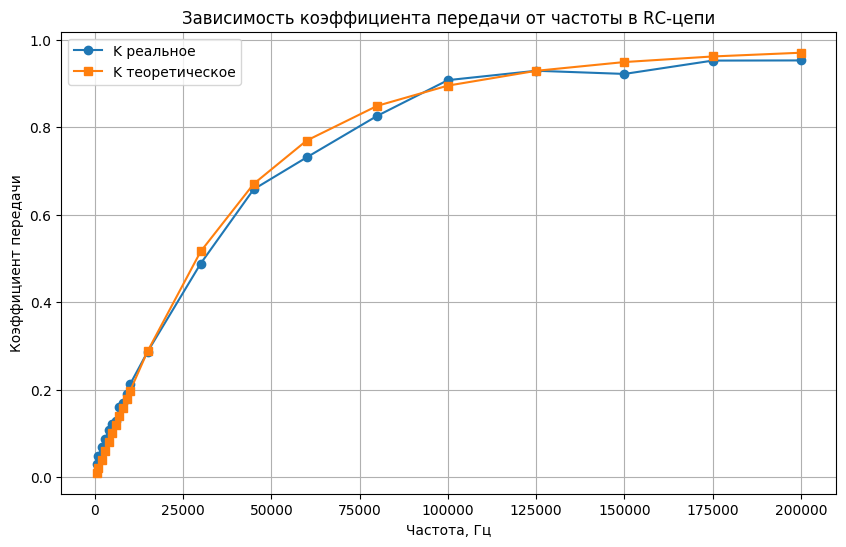

In [ ]:
df = T_RC.dropna()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['K'], label='K реальное', marker='o')
plt.plot(df.index, df['K theory'], label='K теоретическое', marker='s')

plt.xlabel('Частота, Гц')
plt.ylabel('Коэффициент передачи')
plt.title('Зависимость коэффициента передачи от частоты в RС-цепи')
plt.legend()
plt.grid(True, 'both')

# plt.xscale('log')
plt.show()

##### Задание 5

In [ ]:
# INPUT f, Δt, T
f = 10000
d_f = 50
dt = 22.2e-6
d_dt = 0.2e-6
T = 100e-6
d_T = 0.5e-6

omega = 2 * np.pi * f
d_omega = 2 * np.pi * d_f
print("ω =", format_rel(omega, d_omega))

ω = 62832 ± 310, ε=0.5%


$\varphi_{теор} = \arctan-\frac{1}{R \omega C}$

$\Delta_{\varphi_{теор}} = \frac{ -\frac{1}{R \omega C}\sqrt{\left(\frac{\Delta_\omega}{\omega}\right)^2 + \left(\frac{\Delta_L}{L}\right)^2 + \left(\frac{\Delta_R}{R}\right)^2} }{\left(\frac{1}{R \omega C}\right)^2 + 1}$

$\varphi_1= - 2\pi \frac{\Delta t}{T}$

$\Delta_{\varphi_1} = \varphi_1\sqrt{\left(\frac{\Delta_{\Delta t}}{\Delta t}\right)^2 + \left(\frac{\Delta_T}{T}\right)^2}$

In [ ]:
phi_theory = np.arctan(-1/(R1*omega*C3))
d_phi_theory = (-1/(R1*omega*C3))*np.sqrt((d_omega/omega)**2+(d_L1/L1)**2+(d_R1/R1)**2) / ((1/(R1*omega*C3))**2 + 1)
print("φ теор =", format_rel(phi_theory, d_phi_theory))
phi_1 = - 2 * np.pi * dt / T
d_phi_1 = phi_1 * np.sqrt((d_dt/dt)**2 + (d_T/T)**2)
print("φ1 =", format_rel(phi_1, d_phi_1))

φ теор = -1.373 ± 0.027, ε=2%
φ1 = -1.395 ± 0.014, ε=1%


##### Задание 6

In [ ]:
# INPUT 2Uy1 (деления), 2Uymax (деления)
Uy1 = 7
Uymax = 8
d_Uy = 1

$\varphi_2 = -\arcsin{\frac{U_{Y1}}{U_{Ymax}}}$

$\Delta_{\varphi_2} = \frac{U_{Y1}}{U_{Ymax}} \sqrt{\frac{\left(\frac{\Delta_{U_Y}}{U_{Y1}}\right)^2 + \left(\frac{\Delta_{U_Y}}{U_{Ymax}}\right)^2}{1-\left(\frac{U_{Y1}}{U_{Ymax}}\right)^2}}$

In [ ]:
phi_2 = -np.arcsin(Uy1/Uymax)
d_phi_2 = Uy1 / Uymax * np.sqrt(((d_Uy/Uy1)**2 + (d_Uy/Uymax)**2)/(1 - (Uy1/Uymax)**2))
print("φ 2 =", format_rel(phi_2, d_phi_2))

φ 2 = -1.07 ± 0.34, ε=32%


##### Отчёт

In [ ]:
p_RL2 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Сдвиг фаз через сдвиг сигналов (RC)}}
\\begin{{tabular}}{{|c|c|c|c|c|c|}}
\\hline
\\multicolumn{{2}}{{|c|}}{{Измеряем величины}} & \\multicolumn{{4}}{{c|}}{{Вычисляемые величины}} \\\\ \\hline
$f \\pm \\Delta f$ & $\\omega \\pm \\Delta \\omega$ & $\\Delta t \\pm \\Delta (\\Delta t)$ & $T \\pm \\Delta T$ & $\\varphi_1 \\pm \\Delta \\varphi_1$ & $\\varphi_{{\\text{{теор}}}} \\pm \\Delta \\varphi_{{\\text{{теор}}}}$ \\\\
Гц & рад/с & мкс & мкс & рад & рад \\\\ \\hline

{latex_std(f, d_f)} & {latex_std(omega, d_omega)} &
{latex_std(dt, d_dt)} & {latex_std(T, d_T)} &
{latex_std(phi_1, d_phi_1)} & {latex_std(phi_theory, d_phi_theory)} \\\\ \\hline
\\end{{tabular}}
\\end{{table}}"""

# Таблица "Сдвиг фаз через фигуру Лиссажу"
p_RL3 = f"""\\begin{{table}}[H]
\\centering
\\caption{{Сдвиг фаз через фигуру Лиссажу (RC)}}
\\begin{{tabular}}{{|c|c|c|c|c|c|}}
\\hline
\\multicolumn{{3}}{{|c|}}{{Измеряемые величины}} & \\multicolumn{{3}}{{c|}}{{Вычисляемые величины}} \\\\ \\hline
$f \\pm \\Delta f$ & $\\omega \\pm \\Delta \\omega$ & $2U_{{Y1}}$ & $2U_{{Ymax}}$ & $\\varphi_2 \\pm \\Delta \\varphi_2$ & $\\varphi_{{\\text{{теор}}}} \\pm \\Delta \\varphi_{{\\text{{теор}}}}$ \\\\
Гц & рад/с & дел & дел & рад & рад \\\\ \\hline

{latex_std(f, d_f)} & {latex_std(omega, d_omega)} &
{Uy1} & {Uymax} &
{latex_std(phi_2, d_phi_2)} & {latex_std(phi_theory, d_phi_theory)} \\\\ \\hline
\\end{{tabular}}
\\end{{table}}"""

In [ ]:
print(p_RL2)

\begin{table}[H]
\centering
\caption{Сдвиг фаз через сдвиг сигналов}
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multicolumn{2}{|c|}{Измеряем величины} & \multicolumn{4}{c|}{Вычисляемые величины} \\ \hline
$f \pm \Delta f$ & $\omega \pm \Delta \omega$ & $\Delta t \pm \Delta (\Delta t)$ & $T \pm \Delta T$ & $\varphi_1 \pm \Delta \varphi_1$ & $\varphi_{\text{теор}} \pm \Delta \varphi_{\text{теор}}$ \\
Гц & рад/с & мкс & мкс & рад & рад \\ \hline

10000 \pm 50 & 62832 \pm 310 &
0.0000222 \pm 2E-7 & 0.0001000 \pm 5E-7 &
-1.395 \pm 0.014 & -1.373 \pm 0.027 \\ \hline

\end{tabular}
\end{table}


In [ ]:
print(p_RL3)

\begin{table}[H]
\centering
\caption{Сдвиг фаз через фигуру Лиссажу}
\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multicolumn{3}{|c|}{Измеряемые величины} & \multicolumn{2}{c|}{Вычисляемые величины} \\ \hline
$f \pm \Delta f$ & $\omega \pm \Delta \omega$ &  $2U_{Y1}$ & $U_{Ymax} & $\varphi_2 \pm \Delta \varphi_2$ & $\varphi_{\text{теор}} \pm \Delta \varphi_{\text{теор}}$ \\
Гц & рад/с & дел & дел & рад & рад \\ \hline

$10000 \pm 50$ & $62832 \pm 310$ &
$7$ & $8$ &
$-1.07 \pm 0.34$ & $-1.373 \pm 0.027$ \\ \hline

\end{tabular}
\end{table}


In [ ]:
prefix = """\\begin{table}[H]
\\centering
\\caption{Результаты измерений и теоретические значения коэффициента передачи}
\\label{tab:measurements}
\\begin{tabular}{|c|c|c|c|c|}
\\hline
Частота, кГц & $U_{\\text{вх}}$, В & $U_{\\text{вых}}$, В & $K \\pm \\Delta K$ & $K_{\\text{теор}} \\pm \\Delta K_{\\text{теор}}$ \\\\ \\hline
"""

# Генерация строк таблицы
rows = []
for freq, row in T_RC.iterrows():
    # Форматируем числа (убираем лишние нули)
    k_str = latex_std(row['K'], row['ΔK'])
    k_theory_str = latex_std(row['K theory'], row['ΔK theory'])

    # Создаем строку
    row_str = f"{int(freq / 1000) } & {row['U input']} & {row['U output']} & ${k_str}$ & ${k_theory_str}$ \\\\ \\hline"
    rows.append(row_str)

# Суффикс таблицы
suffix = """\\end{tabular}
\\end{table}"""

# Собираем всё вместе
p_RL1 = prefix + "\n".join(rows) + "\n" + suffix

In [ ]:
print(p_RL1)

\begin{table}[H]
\centering
\caption{Результаты измерений и теоретические значения коэффициента передачи}
\label{tab:measurements}
\begin{tabular}{|c|c|c|c|c|}
\hline
Частота, кГц & $U_{\text{вх}}$, В & $U_{\text{вых}}$, В & $K \pm \Delta K$ & $K_{\text{теор}} \pm \Delta K_{\text{теор}}$ \\ \hline
0 & 4.1 & 0.12 & $0.029 \pm 0.005$ & $0.0100 \pm 0.0015$ \\ \hline
1 & 4.08 & 0.2 & $0.049 \pm 0.005$ & $0.020 \pm 0.003$ \\ \hline
2 & 4.12 & 0.28 & $0.068 \pm 0.005$ & $0.040 \pm 0.006$ \\ \hline
3 & 4.1 & 0.36 & $0.088 \pm 0.005$ & $0.060 \pm 0.009$ \\ \hline
4 & 4.08 & 0.44 & $0.108 \pm 0.005$ & $0.080 \pm 0.012$ \\ \hline
5 & 4.1 & 0.5 & $0.122 \pm 0.005$ & $0.100 \pm 0.015$ \\ \hline
6 & 4.08 & 0.52 & $0.127 \pm 0.005$ & $0.120 \pm 0.018$ \\ \hline
7 & 4.0 & 0.64 & $0.160 \pm 0.005$ & $0.139 \pm 0.021$ \\ \hline
8 & 4.0 & 0.68 & $0.170 \pm 0.005$ & $0.159 \pm 0.024$ \\ \hline
9 & 3.98 & 0.76 & $0.191 \pm 0.005$ & $0.178 \pm 0.027$ \\ \hline
10 & 3.96 & 0.84 & $0.212 \pm 0.005$ & $0.20 \